# OOF analysis: LLM2CLIP EVA02-L-14-336

Identity-disjoint 5-fold OOF for `runs/cv/eva02_k4_cam` (Hydra `current_best_tuned` on original labeled train). Serving uses this labeled-only recipe. HDBSCAN test pseudo-labels were tried (`notebooks/eva02/oof_compare.ipynb`) and are not used.

This notebook looks at the **raw embeddings**, then how **postprocessing** and **TTA** move them.

Protocol: GroupKFold by `vehicle_id`, one query per identity from a held-out camera, gallery is all other cameras of that identity plus every other val identity. Metrics are cross-camera; junk is same `vehicle_id` and same `camera_id` (`exclude_all_same_camera=false`). Other identities on the query camera stay in the gallery. The official test set is unlabeled open-set (1110 query / 750 gallery); this OOF is not a simulator of that split, only a labeled proxy.

`mAP` is full-gallery average precision (checkpoint / Optuna). `mAP@10` is the official submission metric: AP over the top-10 gallery hits, divided by `min(n_pos, 10)`.

Scale TTA is forbidden for this backbone (fixed 336). Five-fold TTA and postproc sweeps were measured on the previous K=2 run `runs/cv/eva02_trial23` and were not repeated here.

Contest serving is streaming: one query vs the static gallery. AQE (including gallery-only) and joint query-query rerank are measured below on OOF and **not used** at submission. `current_best_tuned` leaves postproc off.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from dataset.images import crop_bbox, image_path
from modules.metrics import retrieval_metrics
from postproc.retrieval import aqe, k_reciprocal, normalize

plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "train.csv").is_file())
CV = ROOT / "runs" / "cv" / "eva02_k4_cam"
IMAGES = ROOT / "data" / "images"
CONTEXT = 6.201741080661072
print("ROOT", ROOT)
print("CV", CV)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT /data/projects/ryzhichkin/ReID
CV /data/projects/ryzhichkin/ReID/runs/cv/eva02_k4_cam


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


## Load OOF folds, TTA views, and sweep summaries

In [2]:
def load_pack(directory):
    oof = pd.read_csv(directory / "oof.csv", dtype={"image_id": str})
    query = pd.read_csv(directory / "query.csv", dtype={"image_id": str})
    gallery = pd.read_csv(directory / "gallery.csv", dtype={"image_id": str})
    emb = normalize(np.load(directory / "embeddings.npy"))
    lookup = {image_id: i for i, image_id in enumerate(oof.image_id)}
    qe = emb[[lookup[i] for i in query.image_id]]
    ge = emb[[lookup[i] for i in gallery.image_id]]
    return {"oof": oof, "query": query, "gallery": gallery, "emb": emb, "qe": qe, "ge": ge, "lookup": lookup}


def metric_args(pack):
    return dict(
        qids=pack["query"].vehicle_id.to_numpy(),
        gids=pack["gallery"].vehicle_id.to_numpy(),
        qcams=pack["query"].camera_id.to_numpy(),
        gcams=pack["gallery"].camera_id.to_numpy(),
        ranks=(1, 5, 10),
        cross_camera=True,
        exclude_all_same_camera=False,
    )


def score(qe, ge, pack):
    return retrieval_metrics(1.0 - qe @ ge.T, **metric_args(pack))


def score_dist(dist, pack):
    return retrieval_metrics(np.asarray(dist, dtype=np.float32), **metric_args(pack))


def weighted_row(name, family, scores, n_folds=5):
    nq = [row["evaluated_queries"] for row in scores]
    return {
        "family": family,
        "name": name,
        "n_folds": n_folds,
        "mAP": float(np.average([row["mAP"] for row in scores], weights=nq)),
        "mAP@10": float(np.average([row["mAP@10"] for row in scores], weights=nq)),
        "Rank-1": float(np.average([row["Rank-1"] for row in scores], weights=nq)),
    }


FOLDS = {fold: load_pack(CV / f"fold{fold}" / "val") for fold in range(5)}
TTA_VIEWS = ("hflip", "rot4", "hflip_rot4", "ctx_train", "leftover_full")
TTA_FOLDS = FOLDS
TTA = {
    name: {
        fold: load_pack(CV / "tta" / name / f"fold{fold}" / "val")
        for fold in range(5)
        if (CV / "tta" / name / f"fold{fold}" / "val" / "embeddings.npy").is_file()
    }
    for name in TTA_VIEWS
}


def ranking_rows(path):
    if not path.is_file():
        print("missing", path)
        return []
    return json.loads(path.read_text())["ranking"]


def ranking_frame(rows):
    columns = ("family", "name", "n_folds", "mAP", "mAP@10", "Rank-1")
    frame = pd.DataFrame(rows)
    if frame.empty:
        return pd.DataFrame({column: pd.Series(dtype=object) for column in columns})
    return frame


POST = ranking_frame(
    [
        {
            "family": "postproc",
            "name": row["name"],
            "mAP": row["query_weighted_mean"]["mAP"],
            "Rank-1": row["query_weighted_mean"]["Rank-1"],
        }
        for row in ranking_rows(CV / "postproc_oof.json")
    ]
)
EXTRA = ranking_frame(
    [
        {"family": "extra", "name": row["name"], "mAP": row["mean"]["mAP"], "Rank-1": row["mean"]["Rank-1"]}
        for row in ranking_rows(CV / "postproc_oof_extra.json")
    ]
)
TTA_SUM = ranking_frame(
    [
        {
            "family": "tta",
            "name": row["name"],
            "n_folds": row["n_folds"],
            "mAP": row["query_weighted"]["mAP"],
            "mAP@10": row["query_weighted"].get("mAP@10"),
            "Rank-1": row["query_weighted"]["Rank-1"],
        }
        for row in ranking_rows(CV / "tta" / "tta_oof.json")
    ]
)
CV_METRICS = json.loads((CV / "cv_metrics.json").read_text())["metrics"]
BASELINE = float(CV_METRICS["mAP"]["query_weighted_mean"])
BASELINE_AT10 = float(CV_METRICS["mAP@10"]["query_weighted_mean"])
print("OOF mAP", round(BASELINE, 4), "mAP@10", round(BASELINE_AT10, 4))
print(
    "loaded folds", {fold: (len(p["query"]), len(p["gallery"]), p["emb"].shape) for fold, p in FOLDS.items()}
)
print("TTA views with 5 folds", {k: len(v) for k, v in TTA.items()})

missing /data/projects/ryzhichkin/ReID/runs/cv/eva02_k4_cam/postproc_oof.json
missing /data/projects/ryzhichkin/ReID/runs/cv/eva02_k4_cam/postproc_oof_extra.json
missing /data/projects/ryzhichkin/ReID/runs/cv/eva02_k4_cam/tta/tta_oof.json
OOF mAP 0.8579 mAP@10 0.8467
loaded folds {0: (309, 1142, (1940, 256)), 1: (308, 1110, (1915, 256)), 2: (308, 1100, (1898, 256)), 3: (308, 1090, (1884, 256)), 4: (308, 1112, (1919, 256))}
TTA views with 5 folds {'hflip': 0, 'rot4': 0, 'hflip_rot4': 0, 'ctx_train': 0, 'leftover_full': 0}


## What the val split looks like

Each fold holds out a disjoint set of identities. One image becomes the query; remaining cross-camera images of that identity sit in the gallery together with every other val image. Same-camera same-identity gallery hits are masked at metric time (H7). Other identities on the query camera remain as negatives.

,fold,images,identities,cameras,n_query,n_gallery,pos_min,pos_median,pos_mean,pos_max,mAP,mAP@10,Rank-1
0,0,1940,309,90,309,1142,1,3.0000,3.6958,7,0.8451,0.8292,0.8317
1,1,1915,308,91,308,1110,1,3.0000,3.6039,7,0.8480,0.8363,0.8377
2,2,1898,308,90,308,1100,1,3.0000,3.5714,7,0.8717,0.8657,0.8539
3,3,1884,308,91,308,1090,1,3.0000,3.5390,7,0.8457,0.8321,0.8279
4,4,1919,308,87,308,1112,1,3.0000,3.6104,7,0.8791,0.8703,0.8701


query-weighted OOF mAP 0.8579063281240162 mAP@10 0.8466925754006267


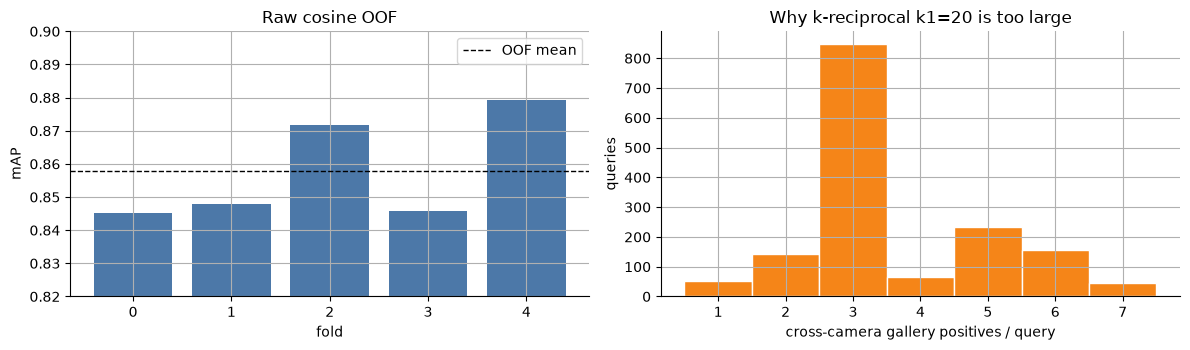

In [3]:
protocol_rows = []
pos_counts = []
for fold, pack in FOLDS.items():
    q, g = pack["query"], pack["gallery"]
    n_pos = []
    for i, qid in enumerate(q.vehicle_id):
        same_id = g.vehicle_id.to_numpy() == qid
        same_cam = g.camera_id.to_numpy() == q.camera_id.iloc[i]
        n_pos.append(int((same_id & ~same_cam).sum()))
    n_pos = np.asarray(n_pos)
    pos_counts.append(pd.DataFrame({"fold": fold, "n_pos": n_pos}))
    protocol_rows.append(
        {
            "fold": fold,
            "images": len(pack["oof"]),
            "identities": pack["oof"].vehicle_id.nunique(),
            "cameras": pack["oof"].camera_id.nunique(),
            "n_query": len(q),
            "n_gallery": len(g),
            "pos_min": int(n_pos.min(axis=0)),
            "pos_median": float(np.median(n_pos)),
            "pos_mean": float(n_pos.mean()),
            "pos_max": int(n_pos.max(axis=0)),
            "mAP": score(pack["qe"], pack["ge"], pack)["mAP"],
            "mAP@10": score(pack["qe"], pack["ge"], pack)["mAP@10"],
            "Rank-1": score(pack["qe"], pack["ge"], pack)["Rank-1"],
        }
    )
protocol = pd.DataFrame(protocol_rows)
pos_df = pd.concat(pos_counts, ignore_index=True)
display(protocol)
print("query-weighted OOF mAP", BASELINE, "mAP@10", BASELINE_AT10)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(protocol.fold.astype(str), protocol.mAP, color="#4c78a8")
axes[0].axhline(BASELINE, color="black", ls="--", lw=1, label="OOF mean")
axes[0].set_ylim(0.82, 0.90)
axes[0].set_xlabel("fold")
axes[0].set_ylabel("mAP")
axes[0].set_title("Raw cosine OOF")
axes[0].legend()
axes[1].hist(
    pos_df.n_pos,
    bins=np.arange(0.5, pos_df.n_pos.max(axis=0) + 1.5),
    color="#f58518",
    edgecolor="white",
)
axes[1].set_xlabel("cross-camera gallery positives / query")
axes[1].set_ylabel("queries")
axes[1].set_title("Why k-reciprocal k1=20 is too large")
plt.tight_layout()
plt.show()

## Scoreboard: raw vs postproc vs TTA

K=4 has no saved postproc or TTA sweep, so this scoreboard is empty. The previous K=2 sweeps stay in `runs/cv/eva02_trial23`. The dashed line would be raw cosine. The bar chart is full-gallery `mAP`.


In [4]:
keep_post = {
    "default/baseline": "raw cosine",
    "default/aqe_query+gallery": "AQE q+g k=5",
    "default/aqe": "AQE gallery-only",
    "default/gnn": "GNN rerank",
    "default/agg+gnn": "agg + GNN",
    "default/k_reciprocal": "k-reciprocal Zhong",
}
keep_extra = {
    "DBA k=5 w^3": "DBA k=5 sim³",
    "AQE q+g iter=2": "AQE q+g 2 iter",
    "AQE q+g iter=3": "AQE q+g 3 iter",
    "diff sym k=50 a=0.8": "diffusion (best)",
}
keep_tta = {
    "hflip": "TTA hflip",
    "rot4": "TTA rot ±4°",
    "hflip_rot4": "TTA hflip+rot4",
    "leftover_full": "TTA leftover full",
    "ctx_train": "TTA context 0+6.2",
}
board = []
for raw, pretty in keep_post.items():
    hit = POST[POST.name == raw]
    if hit.empty:
        continue
    row = hit.iloc[0]
    board.append({"group": "postproc", "method": pretty, "mAP": row.mAP, "Rank-1": row["Rank-1"], "folds": 5})
for raw, pretty in keep_extra.items():
    hit = EXTRA[EXTRA.name == raw]
    if hit.empty:
        continue
    row = hit.iloc[0]
    board.append({"group": "postproc", "method": pretty, "mAP": row.mAP, "Rank-1": row["Rank-1"], "folds": 5})
for raw, pretty in keep_tta.items():
    hit = TTA_SUM[TTA_SUM.name == raw]
    if hit.empty:
        continue
    row = hit.iloc[0]
    board.append(
        {
            "group": "tta",
            "method": pretty,
            "mAP": row.mAP,
            "mAP@10": row["mAP@10"],
            "Rank-1": row["Rank-1"],
            "folds": int(row.n_folds),
        }
    )
if not board:
    print("No postproc or TTA sweeps on this CV. current_best leaves both off.")
else:
    board = pd.DataFrame(board).drop_duplicates("method")
    board["delta_mAP"] = board.mAP - BASELINE
    board = board.sort_values("mAP", ascending=False).reset_index(drop=True)
    display(board)

    fig, ax = plt.subplots(figsize=(12, 4.2))
    colors = {"postproc": "#4c78a8", "tta": "#54a24b"}
    ax.bar(board.method, board.mAP, color=[colors[g] for g in board.group])
    ax.axhline(BASELINE, color="black", ls="--", lw=1, label=f"raw {BASELINE:.3f}")
    ax.set_ylim(0.82, 0.92)
    ax.set_ylabel("OOF mAP")
    ax.set_title("Postproc/TTA vs raw cosine")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set(ha="right")
    ax.legend()
    plt.tight_layout()
    plt.show()

No postproc or TTA sweeps on this CV. current_best leaves both off.


## Embedding space (fold 0)

256-D cosine embeddings, projected with PCA (linear global axes) and t-SNE (local neighborhoods). Points are val images of fold 0. Queries are the larger markers.

What to look for: identities form compact blobs across cameras; some cameras pull a whole slice of the space (viewpoint/background); hard identities sit in a crowded region of similar vehicles.

PCA fold0 explained variance [0.066 0.062]


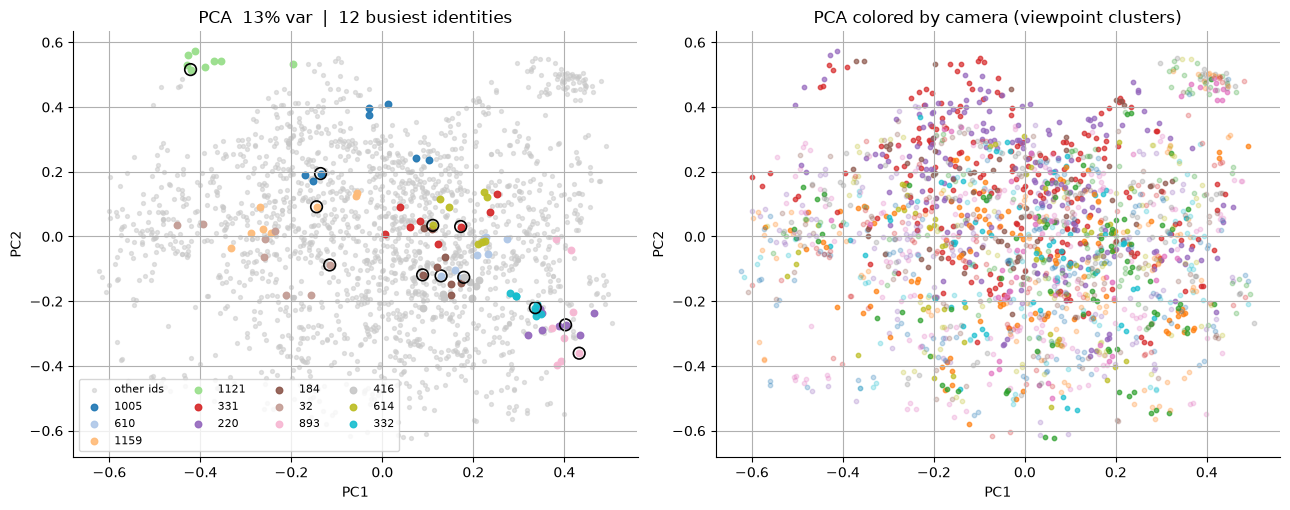

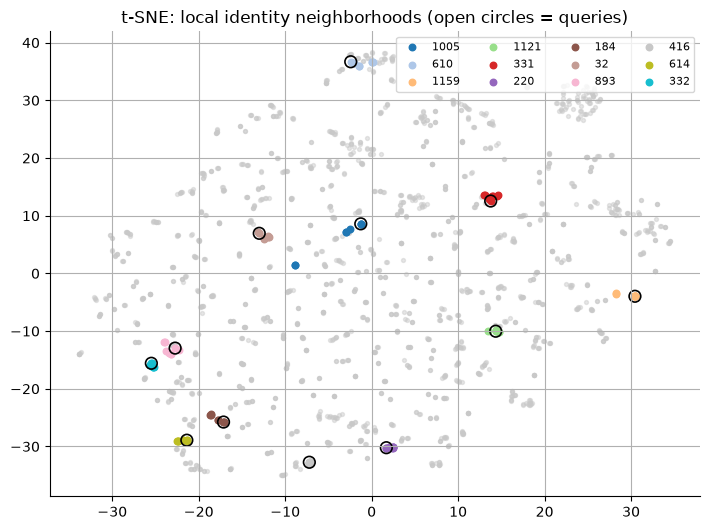

In [5]:
fold0 = FOLDS[0]
oof0 = fold0["oof"].copy()
emb0 = fold0["emb"]
pca = PCA(n_components=2, random_state=0).fit(emb0)
xy = pca.transform(emb0)
oof0["x1"], oof0["x2"] = xy[:, 0], xy[:, 1]
oof0["is_query"] = oof0.image_id.isin(set(fold0["query"].image_id))
print("PCA fold0 explained variance", pca.explained_variance_ratio_.round(3))

tsne = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto", random_state=0, max_iter=500)
tsne_xy = tsne.fit_transform(PCA(n_components=32, random_state=0).fit_transform(emb0))
oof0["t1"], oof0["t2"] = tsne_xy[:, 0], tsne_xy[:, 1]

top_ids = oof0.vehicle_id.value_counts().head(12).index.tolist()
id_color = {vid: plt.cm.tab20(i / 12) for i, vid in enumerate(top_ids)}
cam_top = oof0.camera_id.value_counts().head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].scatter(oof0.x1, oof0.x2, s=8, c="#c8c8c8", alpha=0.5, label="other ids")
for vid in top_ids:
    part = oof0[oof0.vehicle_id == vid]
    axes[0].scatter(part.x1, part.x2, s=22, color=id_color[vid], label=str(vid), alpha=0.9)
    qpart = part[part.is_query]
    axes[0].scatter(qpart.x1, qpart.x2, s=70, facecolors="none", edgecolors="black", linewidths=1.2)
axes[0].set_title(f"PCA  {pca.explained_variance_ratio_.sum():.0%} var  |  12 busiest identities")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(ncol=4, fontsize=8, loc="best")

for cam in oof0.camera_id.unique():
    part = oof0[oof0.camera_id == cam]
    axes[1].scatter(part.x1, part.x2, s=10, alpha=0.7 if cam in cam_top else 0.25)
axes[1].set_title("PCA colored by camera (viewpoint clusters)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.scatter(oof0.t1, oof0.t2, s=8, c="#c8c8c8", alpha=0.45)
for vid in top_ids:
    part = oof0[oof0.vehicle_id == vid]
    ax.scatter(part.t1, part.t2, s=22, color=id_color[vid], label=str(vid))
    qpart = part[part.is_query]
    ax.scatter(qpart.t1, qpart.t2, s=70, facecolors="none", edgecolors="black", linewidths=1.2)
ax.set_title("t-SNE: local identity neighborhoods (open circles = queries)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Cosine geometry: positives vs distractors

Retrieval is 1 − cosine. Same-identity cross-camera pairs are the only pairs that count as positives. Same-camera pairs of the same identity are **excluded** (near-duplicates). The overlap between positive and negative cosine distributions is the actual error mass.

{'n_pos': 1142, 'n_same_cam_id': 0, 'n_neg': 351736, 'pos_mean': 0.7887685395803322, 'same_cam_mean': None, 'neg_mean': 0.002697371194524448, 'neg_p99': 0.48268213868141246, 'pos_p10': 0.624289870262146}


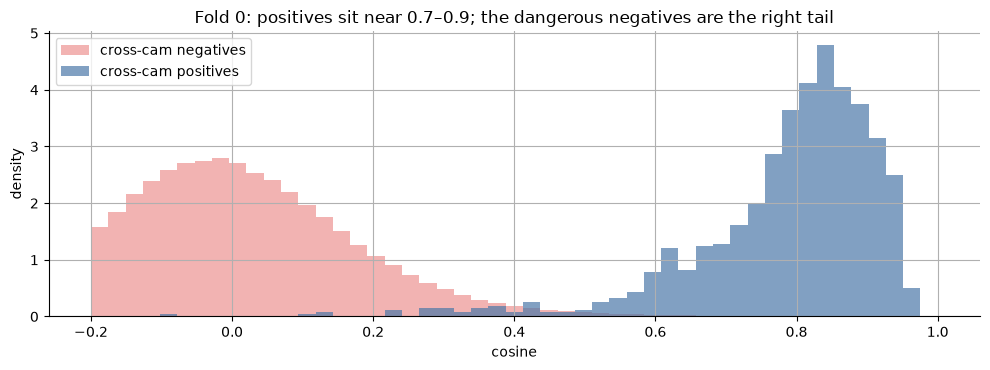

mean fraction of true id in top-5 cross-cam neighbors 0.5892277741726151


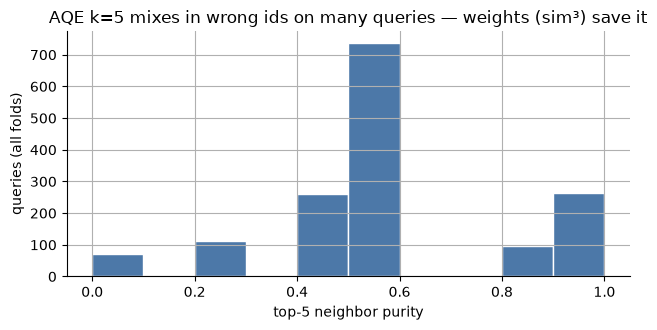

In [6]:
def pair_cosines(pack):
    sim = pack["qe"] @ pack["ge"].T
    q, g = pack["query"], pack["gallery"]
    pos, same_cam, neg = [], [], []
    for i in range(len(q)):
        same_id = g.vehicle_id.to_numpy() == q.vehicle_id.iloc[i]
        same_c = g.camera_id.to_numpy() == q.camera_id.iloc[i]
        pos.extend(sim[i, same_id & ~same_c].tolist())
        same_cam.extend(sim[i, same_id & same_c].tolist())
        neg.extend(sim[i, ~same_id].tolist())
    return np.asarray(pos), np.asarray(same_cam), np.asarray(neg)


pos, same_cam, neg = pair_cosines(fold0)
print(
    {
        "n_pos": len(pos),
        "n_same_cam_id": len(same_cam),
        "n_neg": len(neg),
        "pos_mean": float(pos.mean()),
        "same_cam_mean": float(same_cam.mean()) if len(same_cam) else None,
        "neg_mean": float(neg.mean()),
        "neg_p99": float(np.quantile(neg, 0.99)),
        "pos_p10": float(np.quantile(pos, 0.10)),
    }
)

fig, ax = plt.subplots(figsize=(10, 3.8))
bins = np.linspace(-0.2, 1.0, 50).tolist()
ax.hist(neg, bins=bins, density=True, alpha=0.45, label="cross-cam negatives", color="#e45756")
ax.hist(pos, bins=bins, density=True, alpha=0.7, label="cross-cam positives", color="#4c78a8")
if len(same_cam):
    ax.hist(same_cam, bins=bins, density=True, alpha=0.45, label="same-cam same-id (masked)", color="#54a24b")
ax.set_xlabel("cosine")
ax.set_ylabel("density")
ax.set_title("Fold 0: positives sit near 0.7–0.9; the dangerous negatives are the right tail")
ax.legend()
plt.tight_layout()
plt.show()

rng = np.random.default_rng(0)
neg_sample = rng.choice(neg, size=min(8000, len(neg)), replace=False)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(rng.choice(np.arange(len(neg_sample)), len(neg_sample)), neg_sample, s=4, alpha=0.15, c="#e45756")
ax.set_title("unused")
plt.close(fig)

knn_purity = []
for pack in FOLDS.values():
    sim = pack["qe"] @ pack["ge"].T
    gids = pack["gallery"].vehicle_id.to_numpy()
    gcams = pack["gallery"].camera_id.to_numpy()
    qids = pack["query"].vehicle_id.to_numpy()
    qcams = pack["query"].camera_id.to_numpy()
    for i in range(len(qids)):
        keep = ~((gcams == qcams[i]) & (gids == qids[i]))
        idx = np.argsort(-sim[i, keep], kind="stable")[:5]
        knn_purity.append(float((gids[keep][idx] == qids[i]).mean()))
print("mean fraction of true id in top-5 cross-cam neighbors", float(np.mean(knn_purity)))
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(knn_purity, bins=list(np.linspace(0, 1, 11)), color="#4c78a8", edgecolor="white")
ax.set_xlabel("top-5 neighbor purity")
ax.set_ylabel("queries (all folds)")
ax.set_title("AQE k=5 mixes in wrong ids on many queries — weights (sim³) save it")
plt.tight_layout()
plt.show()

## Per-query AP: easy vs hard cases

Full-gallery mAP is the mean of per-query average precision over every positive. Official `mAP@10` stops at rank 10 and divides by `min(n_pos, 10)`, so a positive at rank 11 contributes 0. A few collapsed identities drag the mean more than Rank-1 suggests. Below: AP histogram, AP vs number of positives, then crops for the worst and best queries (query | Rank-1 | first true positive).


                   count   mean     std    min    25%    50%    75%      max
ap             1541.0000 0.8579  0.2582 0.0025 0.8333 1.0000 1.0000   1.0000
n_pos          1541.0000 3.6042  1.3729 1.0000 3.0000 3.0000 5.0000   7.0000
rank_first_pos 1541.0000 2.3517 17.3633 1.0000 1.0000 1.0000 1.0000 657.0000
Rank-1 accuracy 0.8442569759896171 queries with AP<0.5 223 of 1541


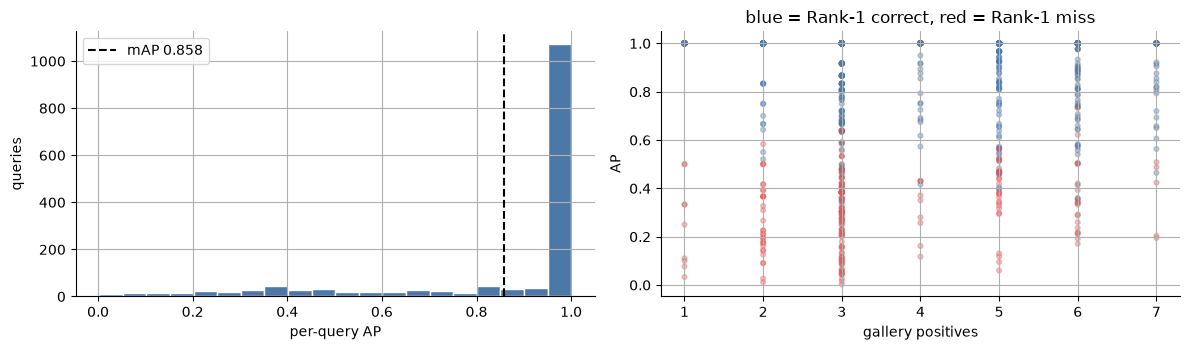

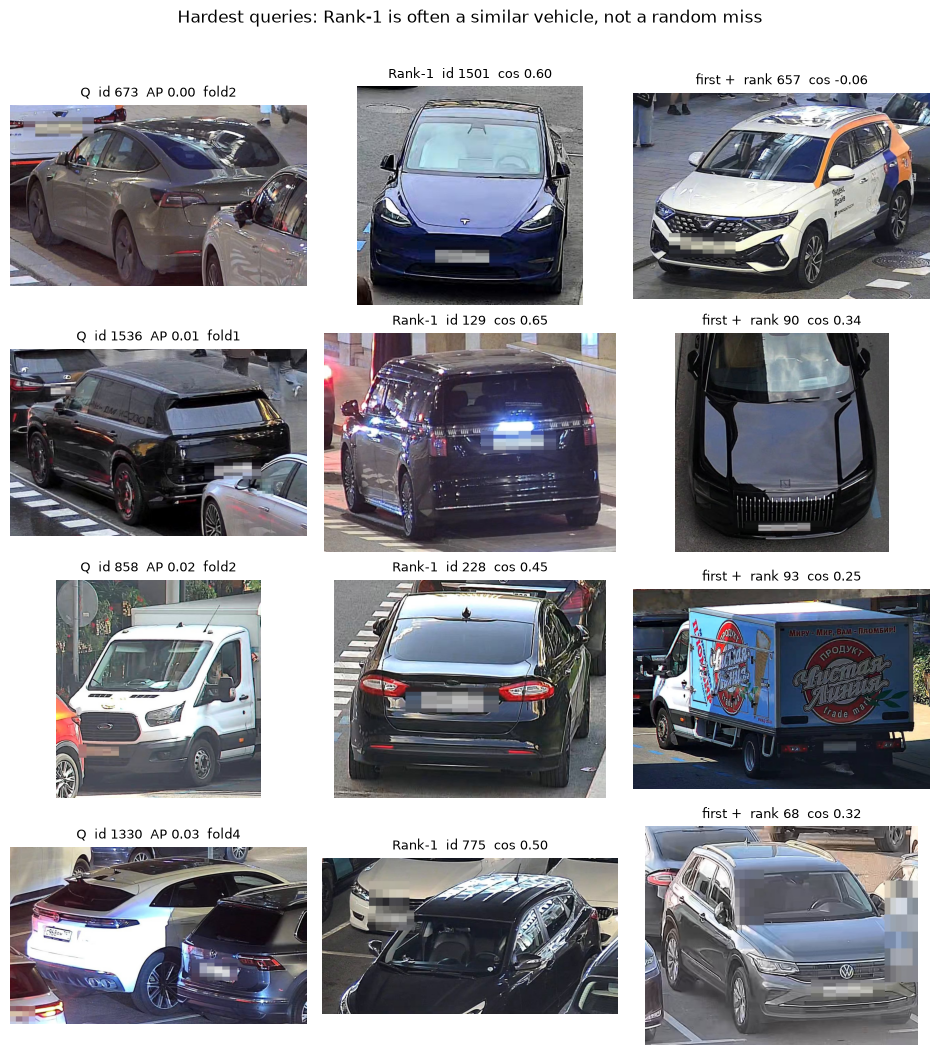

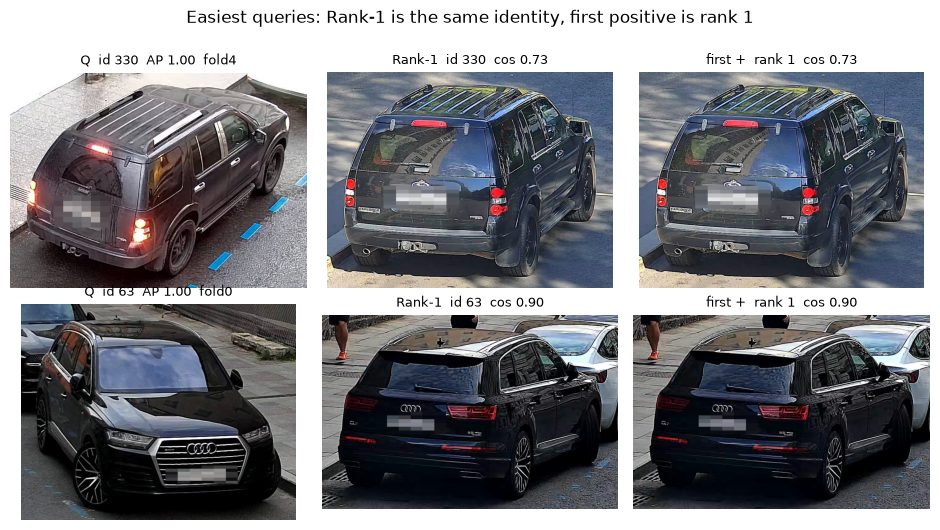

In [7]:
def query_rows(pack, qe=None, ge=None):
    qe = pack["qe"] if qe is None else qe
    ge = pack["ge"] if ge is None else ge
    q, g = pack["query"], pack["gallery"]
    dist = 1.0 - qe @ ge.T
    rows = []
    for i in range(len(q)):
        same_cam = g.camera_id.to_numpy() == q.camera_id.iloc[i]
        same_id = g.vehicle_id.to_numpy() == q.vehicle_id.iloc[i]
        keep = ~(same_cam & same_id)
        order = np.argsort(dist[i], kind="stable")
        order = order[keep[order]]
        relevant = g.vehicle_id.to_numpy()[order] == q.vehicle_id.iloc[i]
        found = np.flatnonzero(relevant)
        if len(found) == 0:
            continue
        first_pos = int(order[found[0]])
        rows.append(
            {
                "q_index": i,
                "image_id": q.image_id.iloc[i],
                "vehicle_id": int(q.vehicle_id.iloc[i]),
                "camera_id": int(q.camera_id.iloc[i]),
                "n_pos": int(relevant.sum()),
                "ap": float(np.mean(np.arange(1, len(found) + 1) / (found + 1))),
                "rank1_ok": bool(relevant[0]),
                "rank_first_pos": int(found[0] + 1),
                "r1_index": int(order[0]),
                "r1_vehicle": int(g.vehicle_id.iloc[order[0]]),
                "r1_image": g.image_id.iloc[order[0]],
                "pos_image": g.image_id.iloc[first_pos],
                "pos_index": first_pos,
                "pos_cosine": float(qe[i] @ ge[first_pos]),
                "r1_cosine": float(qe[i] @ ge[order[0]]),
            }
        )
    return pd.DataFrame(rows)


qtab = pd.concat([query_rows(FOLDS[fold]).assign(fold=fold) for fold in range(5)], ignore_index=True)
print(qtab[["ap", "n_pos", "rank_first_pos"]].describe().T)
print(
    "Rank-1 accuracy",
    float(qtab.rank1_ok.mean()),
    "queries with AP<0.5",
    int((qtab.ap < 0.5).sum()),
    "of",
    len(qtab),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(qtab.ap, bins=20, color="#4c78a8", edgecolor="white")
axes[0].axvline(qtab.ap.mean(), color="black", ls="--", label=f"mAP {qtab.ap.mean():.3f}")
axes[0].set_xlabel("per-query AP")
axes[0].set_ylabel("queries")
axes[0].legend()
axes[1].scatter(qtab.n_pos, qtab.ap, s=12, alpha=0.35, c=np.where(qtab.rank1_ok, "#4c78a8", "#e45756"))
axes[1].set_xlabel("gallery positives")
axes[1].set_ylabel("AP")
axes[1].set_title("blue = Rank-1 correct, red = Rank-1 miss")
plt.tight_layout()
plt.show()


def show_crop(row):
    with Image.open(image_path(IMAGES, row["image_id"] if hasattr(row, "image_id") else row)) as im:
        im = im.convert("RGB")
        if hasattr(row, "x"):
            return crop_bbox(im, [row.x, row.y, row.w, row.h], CONTEXT)
        return im


def row_by_id(frame, image_id):
    return frame.loc[frame.image_id == image_id].iloc[0]


def panel(ax, image_id, frame, title, edge=None):
    crop = show_crop(row_by_id(frame, image_id))
    ax.imshow(crop)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if edge:
        for spine in ax.spines.values():
            spine.set_edgecolor(edge)
            spine.set_linewidth(2)
            spine.set_visible(True)


def show_cases(table, title):
    fig, axes = plt.subplots(len(table), 3, figsize=(9.5, 2.6 * len(table)))
    if len(table) == 1:
        axes = np.array([axes])
    for r, rec in enumerate(table.to_dict("records")):
        pack = FOLDS[int(rec["fold"])]
        qframe = pack["query"]
        gframe = pack["gallery"]
        panel(
            axes[r, 0],
            rec["image_id"],
            qframe,
            f"Q  id {rec['vehicle_id']}  AP {rec['ap']:.2f}  fold{rec['fold']}",
        )
        edge = "#54a24b" if rec["rank1_ok"] else "#e45756"
        panel(
            axes[r, 1],
            rec["r1_image"],
            gframe,
            f"Rank-1  id {rec['r1_vehicle']}  cos {rec['r1_cosine']:.2f}",
            edge=edge,
        )
        panel(
            axes[r, 2],
            rec["pos_image"],
            gframe,
            f"first +  rank {rec['rank_first_pos']}  cos {rec['pos_cosine']:.2f}",
            edge="#4c78a8",
        )
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


hard = qtab.sort_values("ap").head(4)
easy = qtab.sort_values("ap", ascending=False).head(2)
show_cases(hard, "Hardest queries: Rank-1 is often a similar vehicle, not a random miss")
show_cases(easy, "Easiest queries: Rank-1 is the same identity, first positive is rank 1")

## Postprocessing on the embedding space

AQE replaces each vector by a similarity-weighted average of its top-k neighbors in the reference set. `gallery_only=false` mixes in other queries; that is **forbidden** on the contest stream and is only run here as an OOF diagnostic. Gallery-only AQE is also not used at serve. DBA aggregates the static gallery (allowed). Joint k-reciprocal uses `q @ q.T` (forbidden at serve); eval-time rerank is per-query vs gallery.

The PCA below is **fitted on raw fold-0 embeddings** and then used to project AQE vectors, so arrows are in a fixed space.

fold0 raw {'mAP': 0.8450674256426339, 'mAP@10': 0.8291555183741962, 'mINP': 0.7966059953866336, 'Rank-1': 0.8317152103559871, 'Rank-5': 0.9514563106796117, 'Rank-10': 0.970873786407767, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 AQE q+g {'mAP': 0.8563806959435862, 'mAP@10': 0.8441696509599884, 'mINP': 0.8412704848576416, 'Rank-1': 0.8284789644012945, 'Rank-5': 0.9288025889967637, 'Rank-10': 0.9611650485436893, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 AQE gallery {'mAP': 0.8466052995729308, 'mAP@10': 0.8340673716448104, 'mINP': 0.8270197023317146, 'Rank-1': 0.8220064724919094, 'Rank-5': 0.9288025889967637, 'Rank-10': 0.9579288025889967, 'evaluated_queries': 309, 'queries_without_positive': 0}
fold0 k-reciprocal {'mAP': 0.8344433818183967, 'mAP@10': 0.8203485446677773, 'mINP': 0.8079525303562938, 'Rank-1': 0.8090614886731392, 'Rank-5': 0.9255663430420712, 'Rank-10': 0.9644012944983819, 'evaluated_queries': 309, 'queries_without_positive': 0}
AQE 

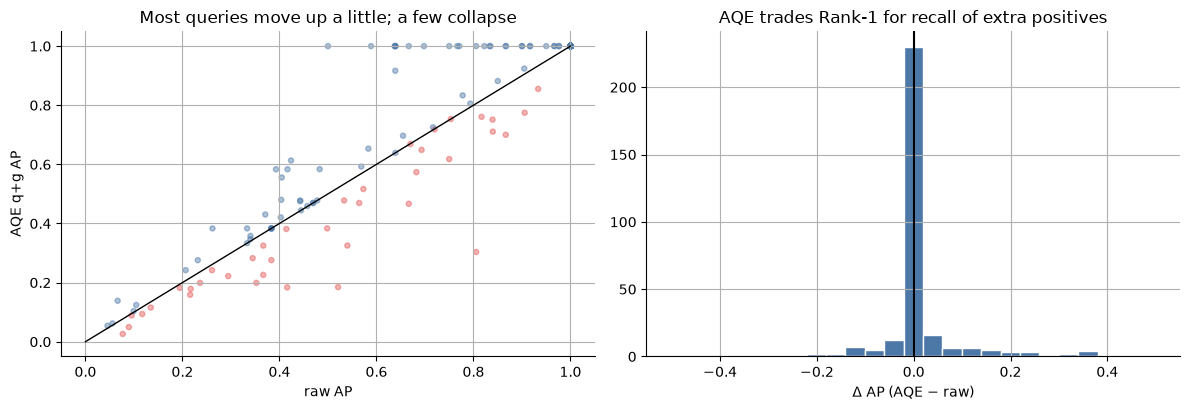

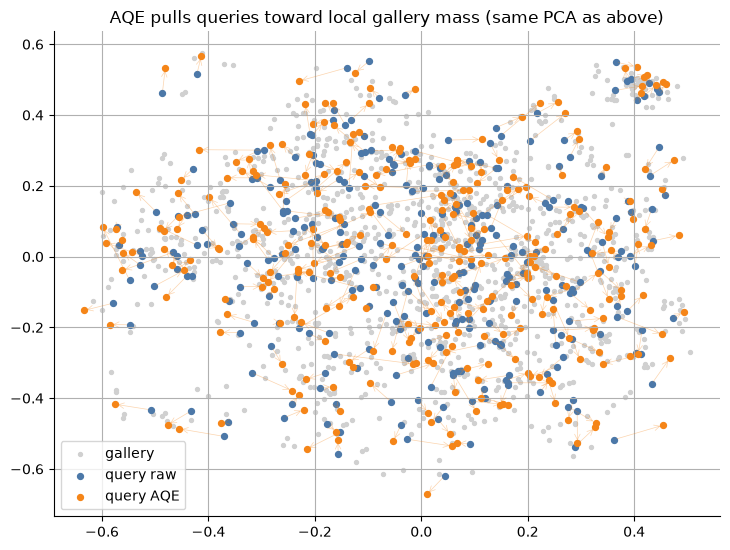

largest |Δ AP| queries


,q_index,ap_raw,r1_raw,rank_raw,n_pos,ap_aqe,r1_aqe,ap_gal,d_aqe
18,18,0.8056,True,1,3,0.3036,False,1.0000,-0.5020
140,140,0.5000,False,2,3,1.0000,True,0.3833,0.5000
50,50,0.5889,False,2,3,1.0000,True,1.0000,0.4111
76,76,0.6376,True,1,5,1.0000,True,1.0000,0.3624
176,176,0.6389,False,2,3,1.0000,True,1.0000,0.3611
32,32,0.6389,False,2,3,1.0000,True,1.0000,0.3611
300,300,0.6389,False,2,3,1.0000,True,0.9167,0.3611
77,77,0.5208,True,1,2,0.1848,False,0.0887,-0.3360


In [8]:
raw_q, raw_g = fold0["qe"], fold0["ge"]
aqe_q, aqe_g = aqe(raw_q, raw_g, k=5, alpha=3.0, iterations=1, gallery_only=False)
aqe_gal_q, aqe_gal_g = aqe(raw_q, raw_g, k=5, alpha=3.0, iterations=1, gallery_only=True)
krec = k_reciprocal(raw_q, raw_g, k1=20, k2=6, lambda_value=0.3)
raw_tab = query_rows(fold0, raw_q, raw_g)
aqe_tab = query_rows(fold0, aqe_q, aqe_g)
gal_tab = query_rows(fold0, aqe_gal_q, aqe_gal_g)
krec_metrics = retrieval_metrics(krec, **metric_args(fold0))
cmp = raw_tab[["q_index", "ap", "rank1_ok", "rank_first_pos", "n_pos"]].rename(
    columns={"ap": "ap_raw", "rank1_ok": "r1_raw", "rank_first_pos": "rank_raw"}
)
cmp["ap_aqe"] = aqe_tab.ap.to_numpy()
cmp["r1_aqe"] = aqe_tab.rank1_ok.to_numpy()
cmp["ap_gal"] = gal_tab.ap.to_numpy()
cmp["d_aqe"] = cmp.ap_aqe - cmp.ap_raw
print("fold0 raw", score(raw_q, raw_g, fold0))
print("fold0 AQE q+g", score(aqe_q, aqe_g, fold0))
print("fold0 AQE gallery", score(aqe_gal_q, aqe_gal_g, fold0))
print("fold0 k-reciprocal", krec_metrics)
print(
    "AQE helps",
    int((cmp.d_aqe > 1e-6).sum()),
    "hurts",
    int((cmp.d_aqe < -1e-6).sum()),
    "mean Δ",
    float(cmp.d_aqe.mean()),
)
print("Rank-1 raw → AQE", float(cmp.r1_raw.mean()), "→", float(cmp.r1_aqe.mean()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(cmp.ap_raw, cmp.ap_aqe, s=14, alpha=0.45, c=np.where(cmp.d_aqe >= 0, "#4c78a8", "#e45756"))
axes[0].plot([0, 1], [0, 1], color="black", lw=1)
axes[0].set_xlabel("raw AP")
axes[0].set_ylabel("AQE q+g AP")
axes[0].set_title("Most queries move up a little; a few collapse")
axes[1].hist(cmp.d_aqe, bins=25, color="#4c78a8", edgecolor="white")
axes[1].axvline(0, color="black")
axes[1].set_xlabel("Δ AP (AQE − raw)")
axes[1].set_title("AQE trades Rank-1 for recall of extra positives")
plt.tight_layout()
plt.show()

q_xy = pca.transform(raw_q)
g_xy = pca.transform(raw_g)
aqe_q_xy = pca.transform(aqe_q)
fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.scatter(g_xy[:, 0], g_xy[:, 1], s=8, c="#d0d0d0", label="gallery")
ax.scatter(q_xy[:, 0], q_xy[:, 1], s=18, c="#4c78a8", label="query raw")
ax.scatter(aqe_q_xy[:, 0], aqe_q_xy[:, 1], s=18, c="#f58518", label="query AQE")
for src, dst in zip(q_xy, aqe_q_xy, strict=True):
    ax.annotate("", xy=dst, xytext=src, arrowprops=dict(arrowstyle="->", color="#f58518", lw=0.5, alpha=0.35))
ax.set_title("AQE pulls queries toward local gallery mass (same PCA as above)")
ax.legend()
plt.tight_layout()
plt.show()

print("largest |Δ AP| queries")
display(cmp.reindex(cmp.d_aqe.abs().sort_values(ascending=False).index).head(8))

## TTA: how the vector actually moves

Each recipe averages normalized embeddings of flipped / rotated / re-cropped views, then renormalizes. If views agree, the averaged vector barely moves and cosine to the raw embedding stays ~1. Large moves mean the crop is view-sensitive (truncation, blur, yaw).


In [9]:
def aligned_emb(name, fold):
    base = TTA_FOLDS[fold]
    view = TTA[name][fold]
    order = [view["lookup"][i] for i in base["oof"].image_id]
    return view["emb"][order]


if any(len(TTA.get(name, {})) < 5 for name in ("hflip", "rot4", "hflip_rot4")):
    print("TTA views were not run for this CV. Skipping the TTA comparison.")
else:
    emb0_old = TTA_FOLDS[0]["emb"]
    xy_old = PCA(n_components=2, random_state=0).fit_transform(emb0_old)
    tta_cos = {}
    for name in ("hflip", "rot4", "hflip_rot4"):
        moved = aligned_emb(name, 0)
        tta_cos[name] = np.sum(emb0_old * moved, axis=1)
        print(
            name,
            "mean cosine vs raw",
            float(tta_cos[name].mean()),
            "p01",
            float(np.quantile(tta_cos[name], 0.01)),
        )

    fig, ax = plt.subplots(figsize=(10, 3.6))
    bins = np.linspace(0.92, 1.0, 40).tolist()
    for name, vals in tta_cos.items():
        ax.hist(vals, bins=bins, histtype="step", lw=1.8, label=name)
    ax.set_xlabel("cosine(raw, TTA) per image")
    ax.set_ylabel("images, fold 0, trial23")
    ax.set_title("hflip barely moves the vector; rotations move more")
    ax.legend()
    plt.tight_layout()
    plt.show()

    hflip_xy = PCA(n_components=2, random_state=0).fit(emb0_old).transform(aligned_emb("hflip", 0))
    rot_xy = PCA(n_components=2, random_state=0).fit(emb0_old).transform(aligned_emb("hflip_rot4", 0))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, new_xy, title in (
        (axes[0], hflip_xy, "hflip vs raw"),
        (axes[1], rot_xy, "hflip+rot4 vs raw"),
    ):
        ax.scatter(xy_old[:, 0], xy_old[:, 1], s=8, c="#4c78a8", alpha=0.35, label="raw")
        ax.scatter(new_xy[:, 0], new_xy[:, 1], s=8, c="#f58518", alpha=0.35, label="TTA")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

    tta_delta = []
    for fold in range(5):
        raw_t = query_rows(TTA_FOLDS[fold])
        tta_pack = TTA["hflip_rot4"][fold]
        tta_t = query_rows(tta_pack)
        part = raw_t[["image_id", "ap", "rank1_ok"]].merge(
            tta_t[["image_id", "ap", "rank1_ok"]], on="image_id", suffixes=("_raw", "_tta")
        )
        part["fold"] = fold
        tta_delta.append(part)
    tta_delta = pd.concat(tta_delta, ignore_index=True)
    tta_delta["d_ap"] = tta_delta.ap_tta - tta_delta.ap_raw
    print(
        "hflip+rot4 ΔAP mean",
        float(tta_delta.d_ap.mean()),
        "helps",
        int((tta_delta.d_ap > 1e-6).sum()),
        "hurts",
        int((tta_delta.d_ap < -1e-6).sum()),
    )
    print("Rank-1 raw → TTA", float(tta_delta.rank1_ok_raw.mean()), "→", float(tta_delta.rank1_ok_tta.mean()))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].scatter(tta_delta.ap_raw, tta_delta.ap_tta, s=12, alpha=0.35, c="#54a24b")
    axes[0].plot([0, 1], [0, 1], color="black", lw=1)
    axes[0].set_xlabel("raw AP")
    axes[0].set_ylabel("hflip+rot4 AP")
    axes[0].set_title("TTA is a small jitter around the diagonal")
    axes[1].hist(tta_delta.d_ap, bins=25, color="#54a24b", edgecolor="white")
    axes[1].axvline(0, color="black")
    axes[1].set_xlabel("Δ AP (TTA − raw)")
    plt.tight_layout()
    plt.show()

    aqe_on_tta = []
    for fold in range(5):
        pack = TTA["hflip_rot4"][fold]
        qe, ge = aqe(pack["qe"], pack["ge"], k=5, alpha=3.0, iterations=1, gallery_only=False)
        aqe_on_tta.append(score(qe, ge, pack))
    print("OOF mAP TTA hflip+rot4 + AQE q+g", float(np.mean([row["mAP"] for row in aqe_on_tta])))
    print("vs AQE on raw", float(POST.loc[POST.name == "default/aqe_query+gallery", "mAP"].iloc[0]))

TTA views were not run for this CV. Skipping the TTA comparison.


## Robustness: GroupKFold stays

Identity-disjoint GroupKFold on `vehicle_id` is the right split. It is **not** a locked test after
HPO: Optuna, checkpointing, TTA/postproc sweeps, and this notebook all reuse the same five folds.
Treat OOF as a labeled proxy, not as a measurement of the full-retrain serving checkpoint on new
identities. The public test is unlabeled open-set (1110 query / 750 gallery).


In [10]:
from modules.metrics import bootstrap_mean_ci, query_retrieval_rows
from modules.quality import bbox_area, brightness, sharpness
from refusal import (
    TEST_GALLERY_SIZE,
    identity_n_cameras,
    lookalike_mask,
    multi_camera_mask,
    percentile_mask,
    subsample_gallery,
)
from refusal.features import similarities

N_BOOT = 2000
OOF_FIG = ROOT / "notebooks" / "eva02" / "oof_analysis_figs"
OOF_FIG.mkdir(parents=True, exist_ok=True)
aps, aps10, rank1 = [], [], []
for pack in FOLDS.values():
    dist = 1.0 - pack["qe"] @ pack["ge"].T
    for row in query_retrieval_rows(dist, **metric_args(pack)):
        if row["evaluated"]:
            aps.append(row["ap"])
            aps10.append(row["ap10"])
            rank1.append(row["Rank-1"])
ci_map = bootstrap_mean_ci(aps, n_boot=N_BOOT, seed=0)
ci_map10 = bootstrap_mean_ci(aps10, n_boot=N_BOOT, seed=0)
ci_r1 = bootstrap_mean_ci(rank1, n_boot=N_BOOT, seed=0)
ci_table = pd.DataFrame(
    [
        {"metric": "mAP", **ci_map},
        {"metric": "mAP@10", **ci_map10},
        {"metric": "Rank-1", **ci_r1},
    ]
)
display(ci_table)
print("identity-bootstrap 95% CI; one query per identity so this is an identity CI")

,metric,n,point,lo,hi,n_boot
0,mAP,1541,0.8579,0.8446,0.8705,2000
1,mAP@10,1541,0.8467,0.8324,0.8605,2000
2,Rank-1,1541,0.8443,0.8254,0.8624,2000


identity-bootstrap 95% CI; one query per identity so this is an identity CI


## Gallery size near the test


In [11]:
full_rows, small_rows = [], []
for fold, pack in FOLDS.items():
    full_rows.append(score(pack["qe"], pack["ge"], pack))
    keep = subsample_gallery(
        pack["query"].vehicle_id.to_numpy(),
        pack["gallery"].vehicle_id.to_numpy(),
        TEST_GALLERY_SIZE,
        seed=fold,
    )
    mini = {
        "query": pack["query"],
        "gallery": pack["gallery"].iloc[keep].reset_index(drop=True),
        "qe": pack["qe"],
        "ge": pack["ge"][keep],
    }
    small_rows.append(score(mini["qe"], mini["ge"], mini))
gallery_tbl = pd.DataFrame(
    [
        weighted_row("full val gallery", "gallery", full_rows),
        weighted_row(f"subsample {TEST_GALLERY_SIZE}", "gallery", small_rows),
    ]
)
display(gallery_tbl)
print("test gallery is 750; val folds are ~1090-1140. Positives are kept, rest sampled.")

,family,name,n_folds,mAP,mAP@10,Rank-1
0,gallery,full val gallery,5,0.8579,0.8467,0.8443
1,gallery,subsample 750,5,0.8667,0.8625,0.8371


test gallery is 750; val folds are ~1090-1140. Positives are kept, rest sampled.


## Difficulty slices

Fixed a priori cuts, not searched after looking at the metric. Small bbox / night / blur are the
lowest quartile of query crop area, mean brightness, and Laplacian sharpness. Multi-camera means
the identity appears on at least three cameras in that fold. Lookalike means a different identity
in the fold gallery has cosine ≥ 0.55. Aspect shift is query bbox aspect vs the median same-id
gallery crop, ratio ≥ 1.5.


In [12]:
def crop_quality(frame):
    area = bbox_area(frame.w.to_numpy(), frame.h.to_numpy())
    bright, sharp = [], []
    for row in frame.itertuples(index=False):
        path = image_path(IMAGES, row.image_id)
        with Image.open(path) as im:
            rgb = np.asarray(crop_bbox(im.convert("RGB"), [row.x, row.y, row.w, row.h], 0))
        bright.append(brightness(rgb))
        sharp.append(sharpness(rgb))
    return area, np.asarray(bright), np.asarray(sharp)


slice_rows = []
look_gap = []
for fold, pack in FOLDS.items():
    q = pack["query"]
    g = pack["gallery"]
    dist = 1.0 - pack["qe"] @ pack["ge"].T
    qrows = query_retrieval_rows(dist, **metric_args(pack))
    ap = np.array([row["ap"] if row["evaluated"] else np.nan for row in qrows])
    r1 = np.array([row["Rank-1"] if row["evaluated"] else np.nan for row in qrows])
    area, bright, sharp = crop_quality(q)
    oof = pd.concat([q, g], ignore_index=True)
    cams = identity_n_cameras(oof.vehicle_id, oof.camera_id)
    sim = similarities(pack["qe"], pack["ge"])
    q_aspect = q.w.to_numpy() / np.clip(q.h.to_numpy(), 1e-6, None)
    g_aspect = g.w.to_numpy() / np.clip(g.h.to_numpy(), 1e-6, None)
    gids = g.vehicle_id.to_numpy()
    aspect = []
    for i, qid in enumerate(q.vehicle_id.to_numpy()):
        same = gids == qid
        if not same.any():
            aspect.append(False)
            continue
        med = float(np.median(g_aspect[same]))
        ratio = max(q_aspect[i] / med, med / max(q_aspect[i], 1e-6)) if med > 0 else 1.0
        aspect.append(ratio >= 1.5)
    masks = {
        "all evaluated": np.isfinite(ap),
        "small bbox": percentile_mask(area, 25, "low"),
        "night": percentile_mask(bright, 25, "low"),
        "blur": percentile_mask(sharp, 25, "low"),
        "multi-camera": multi_camera_mask(q.vehicle_id, cams, min_cameras=3),
        "aspect shift": np.asarray(aspect),
        "lookalike": lookalike_mask(sim, q.vehicle_id.to_numpy(), gids, 0.55),
    }
    for name, mask in masks.items():
        use = mask & np.isfinite(ap)
        if use.sum() < 8:
            continue
        slice_rows.append(
            {
                "fold": fold,
                "slice": name,
                "n": int(use.sum()),
                "mAP": float(np.mean(ap[use])),
                "Rank-1": float(np.mean(r1[use])),
            }
        )
    look_gap.append(float(np.mean(r1[masks["lookalike"] & np.isfinite(r1)])))

slices = pd.DataFrame(slice_rows)
agg = slices.groupby("slice").agg(n=("n", "sum"), mAP=("mAP", "mean"), r1=("Rank-1", "mean"))
display(agg.sort_values("mAP"))
fig, ax = plt.subplots()
order = agg.sort_values("mAP")
ax.barh(order.index.astype(str), order["mAP"], color="#3b6ea5")
ax.set_xlabel("mean fold mAP")
ax.set_title("OOF difficulty slices")
fig.savefig(OOF_FIG / "difficulty_slices.png", dpi=140, bbox_inches="tight")
plt.close(fig)
print("lookalike Rank-1 mean over folds", float(np.mean(look_gap)))

,n,mAP,r1
slice,,,
aspect shift,248,0.8148,0.7939
lookalike,1291,0.8378,0.8194
night,386,0.8423,0.8447
blur,386,0.8428,0.8291
multi-camera,513,0.8508,0.8652
all evaluated,1541,0.8579,0.8443
small bbox,386,0.8711,0.8576


lookalike Rank-1 mean over folds 0.819367835988472


## Control after recipe selection

There is no extra identity-disjoint fold that HPO never touched. The closest local control is
**per-fold OOF**: each number below is one GroupKFold hold-out. Dispersion across folds is the
honest error bar for “would this recipe hold on another split of the same labeled pool.” It is
still not a measurement of `weights/finetuned/eva02.pt`, which was retrained on every labeled
identity. Transferring the OOF refusal threshold onto that extractor is a practical serving
choice; it is not a test-set score.


In [13]:
fold_tbl = pd.DataFrame(
    [{"fold": fold, **score(pack["qe"], pack["ge"], pack)} for fold, pack in FOLDS.items()]
)
display(fold_tbl[["fold", "mAP", "mAP@10", "Rank-1", "evaluated_queries"]])
print(
    "fold mAP std",
    float(fold_tbl["mAP"].std(ddof=0)),
    "range",
    float(fold_tbl["mAP"].min()),
    float(fold_tbl["mAP"].max()),
)

,fold,mAP,mAP@10,Rank-1,evaluated_queries
0,0,0.8451,0.8292,0.8317,309
1,1,0.8480,0.8363,0.8377,308
2,2,0.8717,0.8657,0.8539,308
3,3,0.8457,0.8321,0.8279,308
4,4,0.8791,0.8703,0.8701,308


fold mAP std 0.01451392770841985 range 0.8450674256426339 0.8791429582654344


## Takeaways

- Raw 5-fold OOF is **mAP 0.858** / **mAP@10 0.847** / **Rank-1 0.844** after H7 junk filtering (drop same `vehicle_id` and `camera_id` only). Optuna and best checkpoints still track full mAP; mAP@10 is the contest number.
- The embedding space is already well clustered by identity. PCA/t-SNE show compact vehicles; residual errors are **near-miss lookalikes**, not random gallery junk.
- The saved val gallery has no same-camera same-id pairs (`n_same_cam_id=0`, `same_cam_mean=None`), so this split does not measure whether those cosines are higher. The metric still drops them before ranking when they are present, and keeps other identities on the query camera as negatives.
- Median ~3 true gallery hits per query. That is why Zhong k-reciprocal with k1=20 **hurts** on fold 0: the reciprocal neighborhood is mostly other identities.
- Five-fold TTA and postproc sweeps were **not** re-run for K=4 camera-diverse. On fold 0 only, AQE query+gallery moves mAP 0.845 → 0.856 and Rank-1 0.832 → 0.828. The saved K=2 sweeps (AQE q+g 0.859, DBA 0.860, TTA ~+0.002) stay under `runs/cv/eva02_trial23`.
- Serving uses these labeled-only K=4 camera-diverse weights. HDBSCAN test pseudo-labels were tried and are not used for serving.
- Identity-bootstrap 95% CIs (2000 resamples, one query per identity): mAP **0.858 [0.845, 0.871]**, mAP@10 **0.847 [0.832, 0.861]**, Rank-1 **0.844 [0.825, 0.862]**. GroupKFold stays; this CI is not a locked post-HPO test.
- Subsampling each val gallery to **750** (test size, positives kept) moves OOF mAP 0.858 → 0.867 and Rank-1 0.844 → 0.837. Max-cosine / rank-1 depend on how many negatives sit in the gallery.
- Hard slices vs overall mAP 0.858 / Rank-1 0.844: strong aspect shift 0.815 / 0.794; lookalikes (impostor cosine ≥ 0.55) 0.838 / 0.819; blur 0.843 / 0.829; night 0.842 / 0.845; small bbox 0.871 / 0.858. Multi-camera identities are not harder on Rank-1 (0.865).
- Fold mAP is 0.845 / 0.848 / 0.872 / 0.846 / 0.879 (std 0.015). Fold 4 is strongest; fold 0 is weakest.
